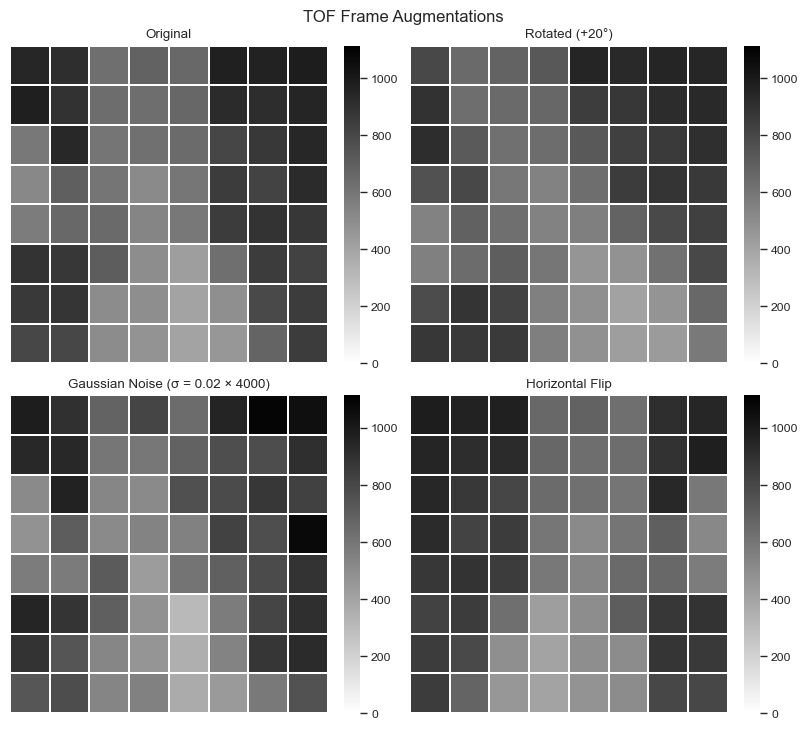

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# For reproducible noise in the paper, fix a seed (change/remove if not desired)
np.random.seed(42)

# --- Augmentation functions ---
def add_gaussian_noise(sip, noise_level=0.05):
    """Add Gaussian noise with a fraction of max possible value (4000)."""
    max_possible_val = 4000
    std_dev = noise_level * max_possible_val
    noise = np.random.normal(0, std_dev, sip.shape)
    noisy_sip = sip + noise
    return np.clip(noisy_sip, a_min=0.0, a_max=None)

def flip_horizontal(sip):
    """Flip 8x8 frames horizontally for all time steps in sip (T, 64)."""
    flipped = []
    for frame in sip:
        frame_8x8 = frame.reshape(8, 8)
        flipped_frame = np.fliplr(frame_8x8).flatten()
        flipped.append(flipped_frame)
    return np.array(flipped, dtype=np.float32)

def rotate_frame(frame, angle):
    """Rotate a single 8x8 frame by a given angle (in degrees)."""
    from scipy.ndimage import rotate
    frame_8x8 = frame.reshape(8, 8)
    rotated = rotate(frame_8x8, angle, reshape=False, order=1, mode='nearest')
    return rotated.flatten()

# --- Your 8×8 TOF data ---
data = np.array([
    [946, 912, 630, 687, 658, 972, 965, 983],
    [975, 892, 637, 632, 665, 923, 915, 952],
    [590, 936, 601, 624, 646, 805, 866, 941],
    [520, 696, 601, 513, 599, 848, 821, 922],
    [571, 660, 650, 532, 590, 850, 891, 873],
    [890, 871, 705, 499, 425, 628, 848, 822],
    [861, 881, 503, 494, 403, 491, 793, 848],
    [804, 801, 504, 472, 404, 456, 674, 850]
], dtype=float)

# --- Prepare augmented versions ---
original = data.copy()
rotated = rotate_frame(original.flatten(), angle=20).reshape(8, 8)
noise_level = 0.02
noisy_flat = add_gaussian_noise(original.flatten().reshape(1, -1), noise_level=noise_level)[0]
noisy = noisy_flat.reshape(8, 8)
flipped_flat = flip_horizontal(original.flatten().reshape(1, -1))[0]
flipped = flipped_flat.reshape(8, 8)

# --- Set consistent color scale ---
all_mats = np.stack([original, rotated, noisy, flipped], axis=0)
vmin = 0.0
vmax = np.max(all_mats) * 1.02

# --- Plotting ---
sns.set_context("paper", font_scale=1.0)
sns.set_style("white")
fig, axes = plt.subplots(2, 2, figsize=(8, 7), constrained_layout=False)

plots = [
    ("Original", original),
    ("Rotated (+20°)", rotated),
    ("Gaussian Noise (σ = 0.02 × 4000)", noisy),
    ("Horizontal Flip", flipped),
]

for ax, (title, mat) in zip(axes.ravel(), plots):
    sns.heatmap(
        mat,
        ax=ax,
        # cmap="coolwarm",
        cmap="gray_r",
        vmin=vmin,
        vmax=vmax,
        cbar=True,
        square=True,
        linewidths=0.3,
        linecolor="white",
        xticklabels=False,
        yticklabels=False
    )
#     sns.heatmap(
#     mat,
#     ax=ax,
#     cmap="viridis",
#     cbar=True,
#     square=True,
#     linewidths=0.3,
#     linecolor="white",
#     xticklabels=False,
#     yticklabels=False
# )


    ax.set_title(title)

fig.suptitle("TOF Frame Augmentations", y=1.02, fontsize=12)
fig.savefig("tof_heatmaps_augmentations.pdf")
fig.savefig("tof_heatmaps_augmentations.svg")
plt.show()

In [3]:
{
 "cells": [
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "import numpy as np\n",
    "import matplotlib.pyplot as plt\n",
    "import seaborn as sns\n",
    "\n",
    "# For reproducible noise in the paper, fix a seed (change/remove if not desired)\n",
    "np.random.seed(42)\n",
    "\n",
    "# --- Augmentation functions ---\n",
    "def add_gaussian_noise(sip, noise_level=0.05):\n",
    "    \"\"\"Add Gaussian noise with a fraction of max possible value (4000).\"\"\"\n",
    "    max_possible_val = 4000\n",
    "    std_dev = noise_level * max_possible_val\n",
    "    noise = np.random.normal(0, std_dev, sip.shape)\n",
    "    noisy_sip = sip + noise\n",
    "    return np.clip(noisy_sip, a_min=0.0, a_max=None)\n",
    "\n",
    "def flip_horizontal(sip):\n",
    "    \"\"\"Flip 8x8 frames horizontally for all time steps in sip (T, 64).\"\"\"\n",
    "    flipped = []\n",
    "    for frame in sip:\n",
    "        frame_8x8 = frame.reshape(8, 8)\n",
    "        flipped_frame = np.fliplr(frame_8x8).flatten()\n",
    "        flipped.append(flipped_frame)\n",
    "    return np.array(flipped, dtype=np.float32)\n",
    "\n",
    "def rotate_frame(frame, angle):\n",
    "    \"\"\"Rotate a single 8x8 frame by a given angle (in degrees).\"\"\"\n",
    "    from scipy.ndimage import rotate\n",
    "    frame_8x8 = frame.reshape(8, 8)\n",
    "    rotated = rotate(frame_8x8, angle, reshape=False, order=1, mode='nearest')\n",
    "    return rotated.flatten()\n",
    "\n",
    "# --- Your 8×8 TOF data ---\n",
    "data = np.array([\n",
    "    [946, 912, 630, 687, 658, 972, 965, 983],\n",
    "    [975, 892, 637, 632, 665, 923, 915, 952],\n",
    "    [590, 936, 601, 624, 646, 805, 866, 941],\n",
    "    [520, 696, 601, 513, 599, 848, 821, 922],\n",
    "    [571, 660, 650, 532, 590, 850, 891, 873],\n",
    "    [890, 871, 705, 499, 425, 628, 848, 822],\n",
    "    [861, 881, 503, 494, 403, 491, 793, 848],\n",
    "    [804, 801, 504, 472, 404, 456, 674, 850]\n",
    "], dtype=float)\n",
    "\n",
    "# --- Prepare augmented versions ---\n",
    "original = data.copy()\n",
    "rotated = rotate_frame(original.flatten(), angle=20).reshape(8, 8)\n",
    "noise_level = 0.02\n",
    "noisy_flat = add_gaussian_noise(original.flatten().reshape(1, -1), noise_level=noise_level)[0]\n",
    "noisy = noisy_flat.reshape(8, 8)\n",
    "flipped_flat = flip_horizontal(original.flatten().reshape(1, -1))[0]\n",
    "flipped = flipped_flat.reshape(8, 8)\n",
    "\n",
    "# --- Set consistent color scale ---\n",
    "all_mats = np.stack([original, rotated, noisy, flipped], axis=0)\n",
    "vmin = 0.0\n",
    "vmax = np.max(all_mats) * 1.02\n",
    "\n",
    "# --- Plotting with NO WHITE SPACE between heatmaps ---\n",
    "sns.set_context(\"paper\", font_scale=1.0)\n",
    "sns.set_style(\"white\")\n",
    "fig, axes = plt.subplots(2, 2, figsize=(8, 7), constrained_layout=False)\n",
    "\n",
    "plots = [\n",
    "    (\"Original\", original),\n",
    "    (\"Rotated (+20°)\", rotated),\n",
    "    (\"Gaussian Noise (σ = 0.02 × 4000)\", noisy),\n",
    "    (\"Horizontal Flip\", flipped),\n",
    "]\n",
    "\n",
    "for ax, (title, mat) in zip(axes.ravel(), plots):\n",
    "    sns.heatmap(\n",
    "        mat,\n",
    "        ax=ax,\n",
    "        cmap=\"gray_r\",\n",
    "        vmin=vmin,\n",
    "        vmax=vmax,\n",
    "        cbar=True,\n",
    "        square=True,\n",
    "        linewidths=0.3,\n",
    "        linecolor=\"white\",\n",
    "        xticklabels=False,\n",
    "        yticklabels=False\n",
    "    )\n",
    "    ax.set_title(title)\n",
    "\n",
    "# Remove ALL gaps between subplots - this is the key change!\n",
    "plt.subplots_adjust(wspace=0.0, hspace=0.0)\n",
    "\n",
    "fig.suptitle(\"TOF Frame Augmentations\", y=1.02, fontsize=12)\n",
    "fig.savefig(\"tof_heatmaps_augmentations_compact.pdf\", bbox_inches='tight', pad_inches=0)\n",
    "fig.savefig(\"tof_heatmaps_augmentations_compact.svg\", bbox_inches='tight', pad_inches=0)\n",
    "plt.show()"
   ]
  }
 ],
 "metadata": {
  "kernelspec": {
   "display_name": "ACM1",
   "language": "python",
   "name": "python3"
  },
  "language_info": {
   "codemirror_mode": {
    "name": "ipython",
    "version": 3
   },
   "file_extension": ".py",
   "mimetype": "text/x-python",
   "name": "python",
   "name": "python",
   "nbconvert_exporter": "python",
   "pygments_lexer": "ipython3",
   "version": "3.12.9"
  }
 },
 "nbformat": 4,
 "nbformat_minor": 2
}

NameError: name 'null' is not defined